# Training a Variational Autoencoder (VAE) on MNIST : Practice & Experimetns

**Authored by Alexandre Mathias DONNAT - Télécom Paris**

## Data loading
Let's import some libraries and load the MNIST dataset.

In [1]:
# prerequisites
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.autograd import Variable
from torchvision.utils import save_image
import matplotlib.pyplot as plt
import IPython.display
import numpy as np

bs = 100

# MNIST Dataset
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=bs, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=bs, shuffle=False)

## Architecture specification

We can use the following encoder (don't forget that in a VAE the encoder has two heads, for the mean and the variance):
```
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc31): Linear(in_features=256, out_features=2, bias=True)
  (fc32): Linear(in_features=256, out_features=2, bias=True)
```
and this decoder:
```
  (fc4): Linear(in_features=2, out_features=256, bias=True)
  (fc5): Linear(in_features=256, out_features=512, bias=True)
  (fc6): Linear(in_features=512, out_features=784, bias=True)
```
Then, we need to complete the forward function. We can use Relu activations for every layer except for the heads that can reach negative values. Concerning the decoder head, we can use sigmoid to obtain values in [0,1].

Here we consider a latent space of dimension 2 but is could be any *zdim* dimension.

In [2]:
class VAE(nn.Module):
    def __init__(self, x_dim, h_dim1, h_dim2, z_dim):
        super(VAE, self).__init__()

        # encoder part
        self.fc1 = nn.Linear(x_dim, h_dim1)
        self.fc2 = nn.Linear(h_dim1, h_dim2)
        self.fc31 = nn.Linear(h_dim2, z_dim)  # mu head
        self.fc32 = nn.Linear(h_dim2, z_dim)  # log_var head

        # decoder part
        self.fc4 = nn.Linear(z_dim, h_dim2)
        self.fc5 = nn.Linear(h_dim2, h_dim1)
        self.fc6 = nn.Linear(h_dim1, x_dim)

    def encoder(self, x):
        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))
        mu = self.fc31(h)
        log_var = self.fc32(h)
        return mu, log_var

    def decoder(self, z):
        h = F.relu(self.fc4(z))
        h = F.relu(self.fc5(h))
        return torch.sigmoid(self.fc6(h))  # values in [0, 1]

    def sampling(self, mu, log_var):
        # reparameterization trick
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.sampling(mu, log_var)
        x_rec = self.decoder(z)
        return x_rec, mu, log_var

## Loss function
The total loss of the VAE is composed of two terms: a reconstruction term and the KL divergence with the Prior.

Assuming a standard prior $\mathcal{N}(0,Id)$ for $p(z)$ and a Gaussian $\mathcal{N}(\mu, \mathsf{diag}(\sigma))$ for $q(z|x)$, we recall that
$$ KL( q(z|x) \parallel p(z) ) = \frac{1}{2} \left[ - \sum_i (1 + \log \sigma_i^2) + \sum_i \sigma_i^2 + \sum_i \mu_i^2 \right] .$$

In [ ]:
# build model
vae = VAE(x_dim=784, h_dim1=512, h_dim2=256, z_dim=2)
if torch.cuda.is_available():
    vae.cuda()
optimizer = optim.Adam(vae.parameters())

# return reconstruction error + KL divergence losses
def loss_function(x_rec, x, mu, log_var):
    # Reconstruction loss (Bernoulli likelihood for pixels in [0,1])
    # Use sum to match the usual VAE objective (can divide by batch later if we want)
    RecLoss = F.binary_cross_entropy(x_rec, x, reduction='sum')

    # KL divergence between q(z|x)=N(mu, diag(exp(log_var))) and p(z)=N(0,I)
    # KL = 0.5 * sum( exp(log_var) + mu^2 - 1 - log_var )
    KLDLoss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    return RecLoss + KLDLoss

## Training

We perform training on one epoch. We recommend to debug it using the "main loop" cell later in the page.

In [4]:
for epoch in range(1, 5):
    vae.train()
    train_loss = 0

    for batch_idx, (data, _) in enumerate(train_loader):

        if torch.cuda.is_available():
            data = data.cuda()

        # Flatten images (bs, 1, 28, 28) -> (bs, 784)
        data = data.view(data.size(0), -1)

        optimizer.zero_grad()

        # Forward pass
        x_rec, mu, log_var = vae(data)

        # Compute loss
        loss = loss_function(x_rec, data, mu, log_var)

        # Backprop
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch,
                batch_idx * len(data),
                len(train_loader.dataset),
                100. * batch_idx / len(train_loader),
                loss.item() / len(data)
            ))

    print('====> Epoch: {} Average loss: {:.4f}'.format(
        epoch,
        train_loss / len(train_loader.dataset)
    ))

Train Epoch: 1 [0/60000 (0%)]	Loss: 546.869570
Train Epoch: 1 [10000/60000 (17%)]	Loss: 195.744141
Train Epoch: 1 [20000/60000 (33%)]	Loss: 169.564570
Train Epoch: 1 [30000/60000 (50%)]	Loss: 177.493242
Train Epoch: 1 [40000/60000 (67%)]	Loss: 160.216963
Train Epoch: 1 [50000/60000 (83%)]	Loss: 163.261602
====> Epoch: 1 Average loss: 181.3763
Train Epoch: 2 [0/60000 (0%)]	Loss: 163.929375
Train Epoch: 2 [10000/60000 (17%)]	Loss: 167.640078
Train Epoch: 2 [20000/60000 (33%)]	Loss: 157.679102
Train Epoch: 2 [30000/60000 (50%)]	Loss: 156.409189
Train Epoch: 2 [40000/60000 (67%)]	Loss: 157.185098
Train Epoch: 2 [50000/60000 (83%)]	Loss: 150.417002
====> Epoch: 2 Average loss: 158.5034
Train Epoch: 3 [0/60000 (0%)]	Loss: 165.716055
Train Epoch: 3 [10000/60000 (17%)]	Loss: 151.341699
Train Epoch: 3 [20000/60000 (33%)]	Loss: 158.447520
Train Epoch: 3 [30000/60000 (50%)]	Loss: 155.805127
Train Epoch: 3 [40000/60000 (67%)]	Loss: 148.811504
Train Epoch: 3 [50000/60000 (83%)]	Loss: 142.615117
===

## Visualization:
We provide some visualization functions:

In [6]:
# Create a wall of generated MNIST images
def plotGeneratedImages(generatedImages,dim=(10, 10), figsize=(10, 10)):
    generatedImages=generatedImages.cpu().numpy()
    print(generatedImages.shape)
    plt.figure(figsize=figsize)
    for i in range(generatedImages.shape[0]):
        plt.subplot(dim[0], dim[1], i+1)
        plt.imshow(np.squeeze(generatedImages[i]), interpolation='nearest', cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.savefig('gan_generated_image_epoch_%d.png' % epoch)
    IPython.display.display(IPython.display.Image(data=('gan_generated_image_epoch_%d.png' % epoch)))

## Test

Test the trained VAE by drawing samples from it.

(64, 1, 28, 28)


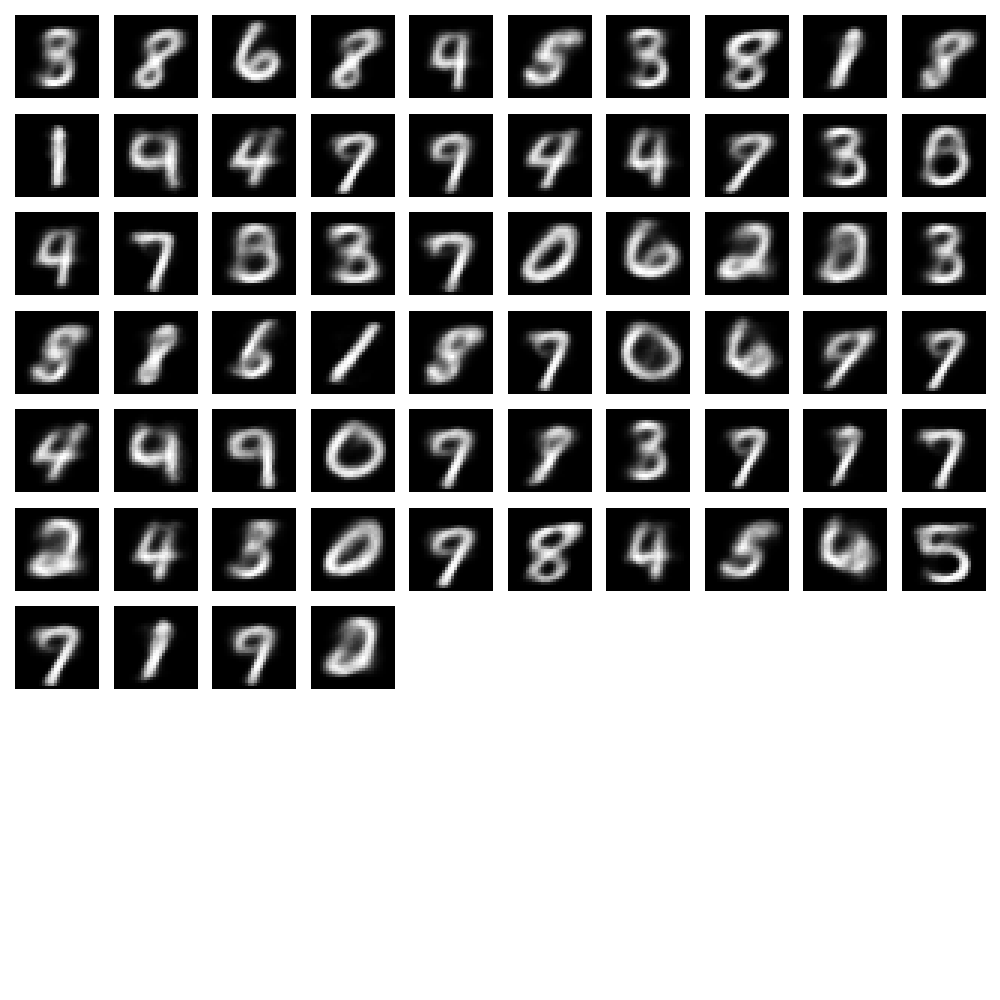

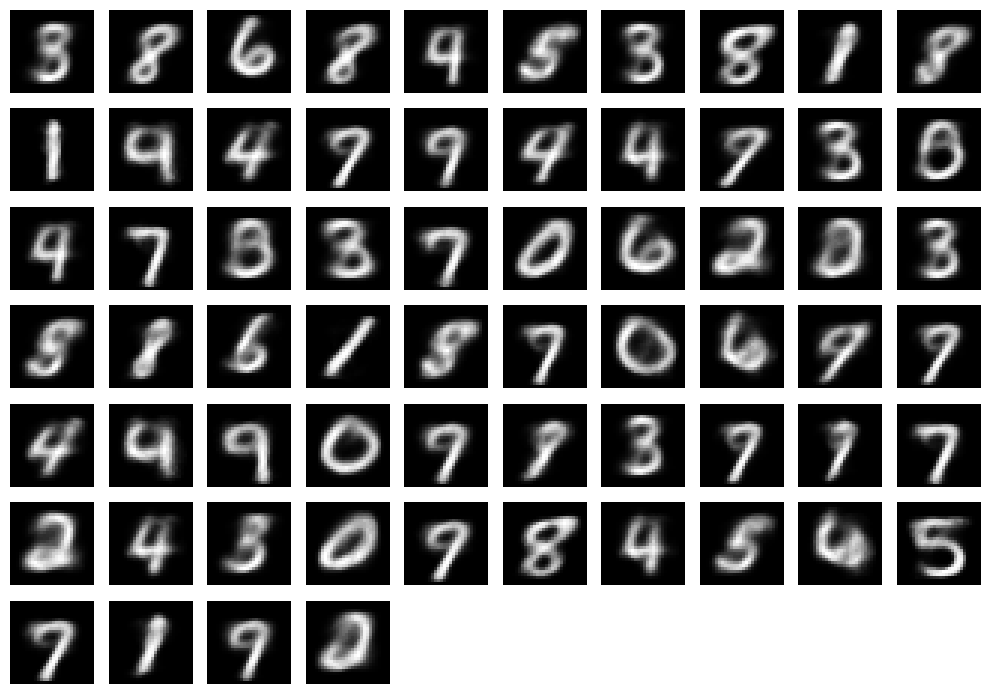

In [8]:
with torch.no_grad():
    z = torch.randn(64, 2)
    if torch.cuda.is_available():
        z = z.cuda()

    generated = vae.decoder(z)

    plotGeneratedImages(generated.view(generated.size(0), 1, 28, 28))
    # save_image(generated.view(64, 1, 28, 28), '.sample_' + '.png')

In [ ]:
vae.eval()
test_loss = 0

with torch.no_grad():
    for data, _ in test_loader:

        if torch.cuda.is_available():
            data = data.cuda()

        data = data.view(data.size(0), -1)

        recon, mu, log_var = vae(data)

        # sum up batch loss
        test_loss += loss_function(recon, data, mu, log_var).item()

test_loss /= len(test_loader.dataset)
print('====> Test set loss: {:.4f}'.format(test_loss))

====> Test set loss: 148.3781


## Bonus 1: Interpolation
Sample two latent vectors z1 and z2 and generate the corresponding images. Then, generate 10 intermediate images by performing linear interpolation in the latent space between the z1 and z2.

(12, 1, 28, 28)


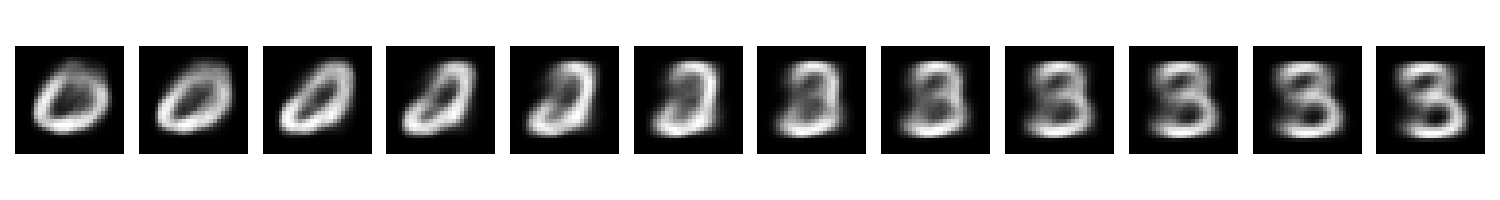

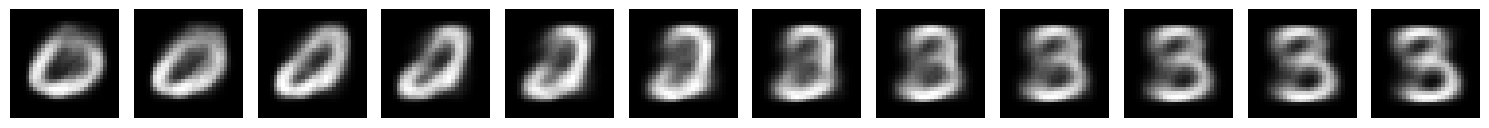

In [ ]:
# Bonus 1: Interpolation in latent space
vae.eval()

with torch.no_grad():

    # Sample two random latent vectors
    z1 = torch.randn(1, 2)
    z2 = torch.randn(1, 2)

    if torch.cuda.is_available():
        z1 = z1.cuda()
        z2 = z2.cuda()

    # Generate endpoints
    img1 = vae.decoder(z1)
    img2 = vae.decoder(z2)

    # Linear interpolation
    alphas = torch.linspace(0, 1, steps=12)  # 2 endpoints + 10 intermediate

    interpolated_images = []

    for alpha in alphas:
        alpha = alpha.to(z1.device)
        z_interp = (1 - alpha) * z1 + alpha * z2
        img_interp = vae.decoder(z_interp)
        interpolated_images.append(img_interp)

    interpolated_images = torch.cat(interpolated_images, dim=0)

    # Display
    plotGeneratedImages(
        interpolated_images.view(interpolated_images.size(0), 1, 28, 28),
        dim=(1, 12),
        figsize=(15, 2)
    )

The interpolation between two latent vectors produces smooth and continuous transitions between digits. Instead of abrupt changes, the digit gradually morphs (e.g., from a 0 to a 3 or from a 7 to an 8), which indicates that the latent space is well structured. This smooth transformation shows that the VAE has learned a meaningful low-dimensional manifold rather than memorizing isolated samples.

## Bonus 2: Visualization
Generate a 10x10 mosaic by sampling *z* over a regulargrid in [-1,1]x[-1,1]. What do we observe?


(100, 1, 28, 28)


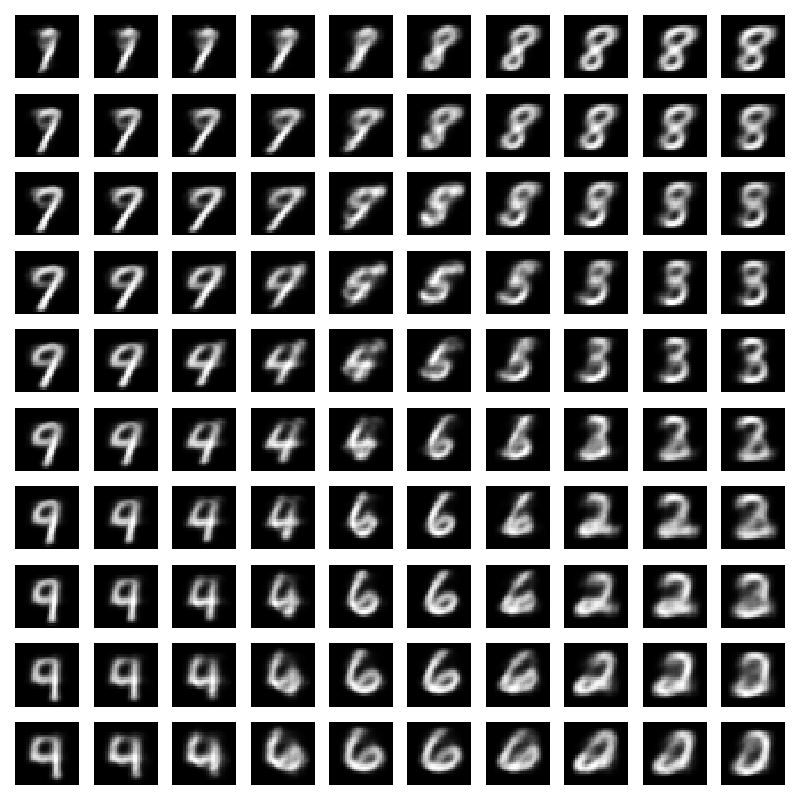

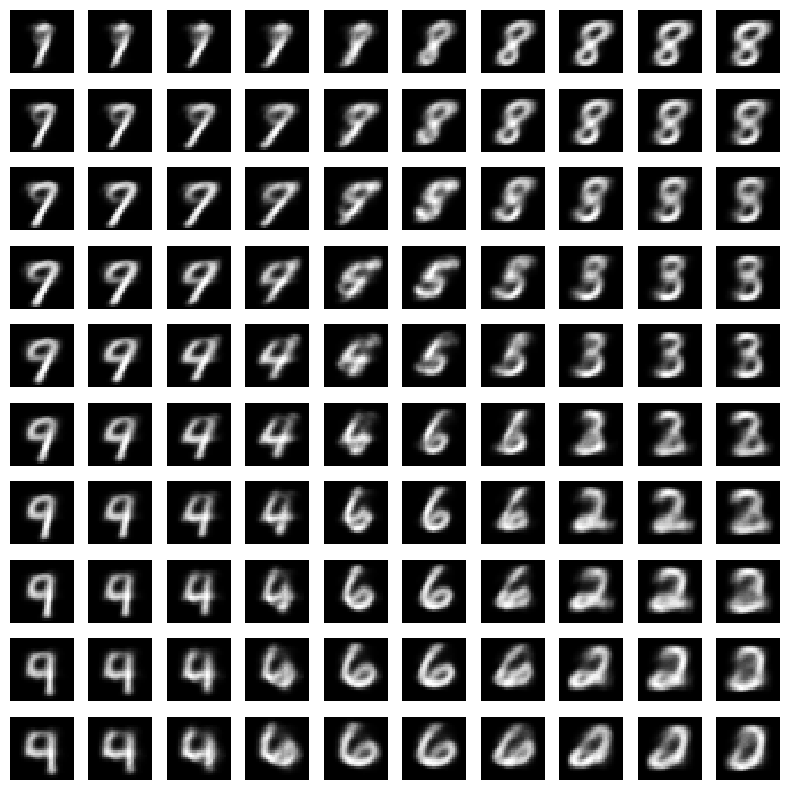

In [ ]:
# Bonus 2: Visualization of the 2D latent space (10x10 grid in [-1,1]x[-1,1])
vae.eval()

with torch.no_grad():
    n = 10
    xs = torch.linspace(-1, 1, steps=n)
    ys = torch.linspace(-1, 1, steps=n)

    imgs = []
    for y in ys:                 # rows
        for x in xs:             # cols
            z = torch.tensor([[x.item(), y.item()]], dtype=torch.float32)
            if torch.cuda.is_available():
                z = z.cuda()
            img = vae.decoder(z)  # (1, 784)
            imgs.append(img)

    grid_imgs = torch.cat(imgs, dim=0)  # (100, 784)

    # display as 10x10 mosaic
    plotGeneratedImages(
        grid_imgs.view(grid_imgs.size(0), 1, 28, 28),
        dim=(n, n),
        figsize=(8, 8)
    )

Sampling the decoder over a regular grid in the 2D latent space reveals organized regions corresponding to different digit types. Neighboring points generate visually similar digits, while distant regions correspond to different classes. This demonstrates that the VAE has learned a continuous and structured latent representation where semantic changes (digit identity) vary smoothly across space.